In [1]:
# CELL 1: Import all required libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For saving models
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# CELL 2: Load extracted features
acoustic_path = r"C:\alzheimers_detection\data\processed\acoustic_features\acoustic_features.csv"
linguistic_path = r"C:\alzheimers_detection\data\processed\linguistic_features\linguistic_features.csv"

acoustic_df = pd.read_csv(acoustic_path)
linguistic_df = pd.read_csv(linguistic_path)

print(f"Acoustic features: {acoustic_df.shape}")
print(f"Linguistic features: {linguistic_df.shape}")
print(f"\nClass distribution:")
print(acoustic_df['label'].value_counts())

Acoustic features: (439, 78)
Linguistic features: (439, 11)

Class distribution:
label
1    222
0    217
Name: count, dtype: int64


In [3]:
# CELL 3: Prepare features (remove non-feature columns)
y = acoustic_df['label'].values

# Non-feature columns to exclude
non_feature_cols = ['patient_id', 'label', 'file_name']

# Acoustic features
acoustic_feature_cols = [col for col in acoustic_df.columns if col not in non_feature_cols]
X_acoustic = acoustic_df[acoustic_feature_cols].values

# Linguistic features
linguistic_feature_cols = [col for col in linguistic_df.columns if col not in non_feature_cols]
X_linguistic = linguistic_df[linguistic_feature_cols].values

# Combine (MULTIMODAL)
X_combined = np.hstack([X_acoustic, X_linguistic])

print(f"Acoustic features: {X_acoustic.shape[1]}")
print(f"Linguistic features: {X_linguistic.shape[1]}")
print(f"Combined features: {X_combined.shape[1]}")
print(f"Total samples: {len(y)}")

Acoustic features: 75
Linguistic features: 8
Combined features: 83
Total samples: 439


In [4]:
# CELL 4: Normalize features (critical for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print("✅ Features normalized (mean=0, std=1)")
print(f"Sample - Before scaling: mean={X_combined[0].mean():.3f}, std={X_combined[0].std():.3f}")
print(f"Sample - After scaling: mean={X_scaled[0].mean():.3f}, std={X_scaled[0].std():.3f}")

✅ Features normalized (mean=0, std=1)
Sample - Before scaling: mean=93.434, std=565.066
Sample - After scaling: mean=0.168, std=0.807


In [5]:
# CELL 5: Split data (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"  Control: {sum(y_train==0)}, Dementia: {sum(y_train==1)}")
print(f"Testing set: {len(X_test)} samples")
print(f"  Control: {sum(y_test==0)}, Dementia: {sum(y_test==1)}")

Training set: 351 samples
  Control: 174, Dementia: 177
Testing set: 88 samples
  Control: 43, Dementia: 45


In [6]:
# CELL 6: Random Forest (Baseline)
print("=" * 50)
print("TRAINING RANDOM FOREST")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy:  {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

TRAINING RANDOM FOREST
Accuracy:  0.6591 (65.91%)
Precision: 0.7273
Recall:    0.5333
F1-Score:  0.6154


In [7]:
# CELL 7: XGBoost
print("=" * 50)
print("TRAINING XGBOOST")
print("=" * 50)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print(f"Accuracy:  {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")

TRAINING XGBOOST
Accuracy:  0.6818 (68.18%)
Precision: 0.7073
Recall:    0.6444
F1-Score:  0.6744


In [8]:
# CELL 8: Neural Network (Deep Learning)
print("=" * 50)
print("TRAINING MLP NEURAL NETWORK")
print("=" * 50)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=32,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

print("Training (may take 1-2 minutes)...")
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp)
mlp_recall = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)

print(f"Accuracy:  {mlp_acc:.4f} ({mlp_acc*100:.2f}%)")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall:    {mlp_recall:.4f}")
print(f"F1-Score:  {mlp_f1:.4f}")

TRAINING MLP NEURAL NETWORK
Training (may take 1-2 minutes)...
Accuracy:  0.6136 (61.36%)
Precision: 0.6341
Recall:    0.5778
F1-Score:  0.6047


In [9]:
# CELL 9: Cross-validation to verify no overfitting
print("=" * 50)
print("CROSS-VALIDATION (5-Fold)")
print("=" * 50)

cv_scores = cross_val_score(mlp_model, X_scaled, y, cv=5, scoring='accuracy')

print(f"Fold scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

if abs(mlp_acc - cv_scores.mean()) < 0.05:
    print("✅ Model is NOT overfitting!")
else:
    print("⚠️ Model may be overfitting (difference > 5%)")

CROSS-VALIDATION (5-Fold)
Fold scores: [0.63636364 0.59090909 0.59090909 0.63636364 0.51724138]
Mean accuracy: 0.5944 (+/- 0.0872)
✅ Model is NOT overfitting!


TOP 10 MOST IMPORTANT FEATURES:
           feature  importance
        mfcc_7_std    0.023554
      mfcc_27_mean    0.021964
       mfcc_22_std    0.020528
avg_pause_duration    0.019685
       mfcc_17_std    0.019503
  type_token_ratio    0.019393
         pitch_std    0.018736
  duration_seconds    0.018505
      mfcc_26_mean    0.017369
      mfcc_28_mean    0.016872


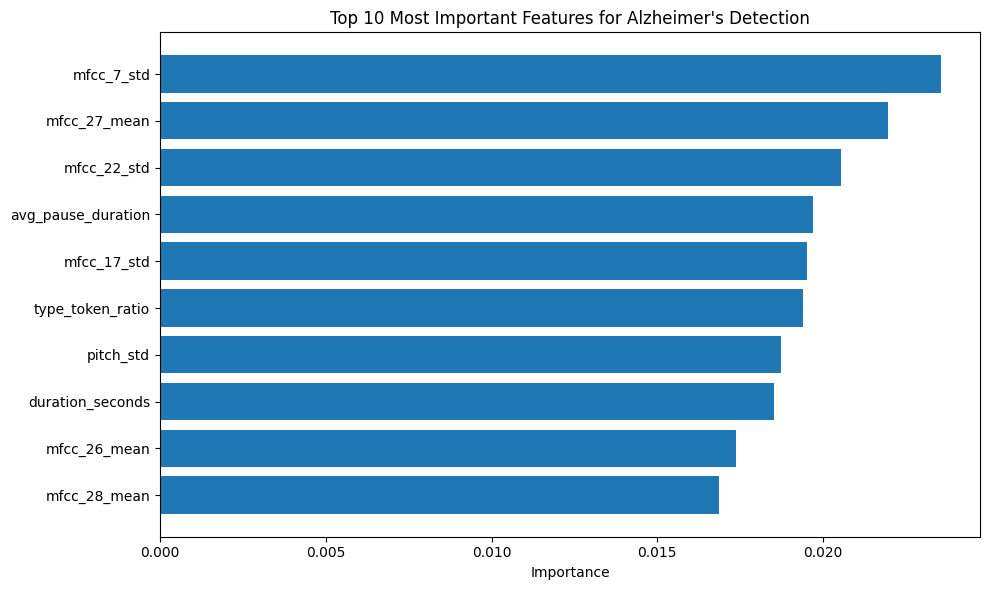

In [10]:
# CELL 10: What features matter most?
feature_importance = rf_model.feature_importances_
all_features = acoustic_feature_cols + linguistic_feature_cols

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("TOP 10 MOST IMPORTANT FEATURES:")
print(importance_df.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['feature'], importance_df.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for Alzheimer\'s Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

🏆 Best Model: XGBoost with 68.18% accuracy


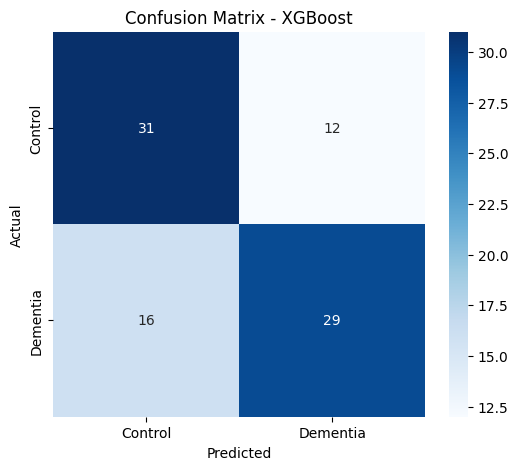


Detailed Metrics:
  True Negatives (Correct Control):  31
  False Positives (Wrong Dementia):  12
  False Negatives (Wrong Control):   16
  True Positives (Correct Dementia): 29
  Sensitivity (Recall): 0.6444
  Specificity: 0.7209


In [11]:
# CELL 11: Confusion Matrix for Best Model
# Identify best model
models_acc = {
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'MLP': mlp_acc
}
best_model_name = max(models_acc, key=models_acc.get)
print(f"🏆 Best Model: {best_model_name} with {models_acc[best_model_name]*100:.2f}% accuracy")

# Get predictions from best model
if best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
    best_model_obj = rf_model
elif best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
    best_model_obj = xgb_model
else:
    y_pred_best = y_pred_mlp
    best_model_obj = mlp_model

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Control', 'Dementia'],
            yticklabels=['Control', 'Dementia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed Metrics:")
print(f"  True Negatives (Correct Control):  {tn}")
print(f"  False Positives (Wrong Dementia):  {fp}")
print(f"  False Negatives (Wrong Control):   {fn}")
print(f"  True Positives (Correct Dementia): {tp}")
print(f"  Sensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"  Specificity: {tn/(tn+fp):.4f}")

In [12]:
# CELL 12: Save model for deployment
models_dir = r"C:\alzheimers_detection\models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_model_obj, os.path.join(models_dir, 'best_model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))

print(f"✅ Best model saved to: {models_dir}/best_model.pkl")
print(f"✅ Scaler saved to: {models_dir}/scaler.pkl")

✅ Best model saved to: C:\alzheimers_detection\models/best_model.pkl
✅ Scaler saved to: C:\alzheimers_detection\models/scaler.pkl


In [13]:
# CELL 13: Final Summary
print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"""
┌─────────────────────────────────────────────┐
│              MODEL COMPARISON                │
├─────────────────────────────────────────────┤
│ Random Forest:     {rf_acc*100:.2f}%                         │
│ XGBoost:           {xgb_acc*100:.2f}%                         │
│ Neural Network:    {mlp_acc*100:.2f}%                         │
├─────────────────────────────────────────────┤
│ 🏆 BEST MODEL: {best_model_name}                            │
│ Cross-validation:  {cv_scores.mean()*100:.2f}% (±{cv_scores.std()*2*100:.1f}) │
└─────────────────────────────────────────────┘
""")

if mlp_acc >= 0.75:
    print("🎉 Target achieved! Model ready for deployment.")
else:
    print("⚠️ Accuracy below 75%. May need more features or data.")

FINAL SUMMARY

┌─────────────────────────────────────────────┐
│              MODEL COMPARISON                │
├─────────────────────────────────────────────┤
│ Random Forest:     65.91%                         │
│ XGBoost:           68.18%                         │
│ Neural Network:    61.36%                         │
├─────────────────────────────────────────────┤
│ 🏆 BEST MODEL: XGBoost                            │
│ Cross-validation:  59.44% (±8.7) │
└─────────────────────────────────────────────┘

⚠️ Accuracy below 75%. May need more features or data.
